# Regressão Logística I
## Tarefa II

Vamos trabalhar com a mesma base do exercício anterior, mas vamos aprofundar um pouco mais a nossa regressão.

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

df = pd.read_csv(url, 
                 names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'])
df['flag_doente'] = (df['num']!=0).astype('int64')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,flag_doente
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


A descrição das variáveis está recortada abaixo:
- age: idade do paciente em anos
- sex: sexo (1 = male; 0 = female)  
- cp: tipo de dor no peito
  - 1: angina típica
  - 2: angina atípica
  - 3: dor não-angina
  - 4: assintomático
- trestbps: pressão sanguínea em repouso (em mm Hg na admissão ao hospital
- chol: colesterol sérico em mg/dl
- fbs: (açúcar no sangue em jejum > 120 mg/dl) (1 = True; 0 = False)
- restecg: resultados eletrocardiográficos em repouso
  - 0: normal
  - 1: tendo anormalidade da onda ST-T (Inversões de onda T e / ou ST com elevação ou depressão de > 0.05 mV)
  - 2: mostrando hipertrofia ventricular esquerda provável ou definitiva pelos critérios de Estes
- thalach: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício(1 = sim; 0 = não)
- oldpeak = Depressão de ST induzida por exercício em relação ao repouso
- slope: Depressão de ST induzida por exercício em relação ao repouso
  - 1: inclinação ascendente
  - 2: estável
  - 3: inclinação descendente
- ca: número de vasos principais (0-3) coloridos por fluorosopia
- thal: 3 = normal; 6 = defeito corrigido; 7 = defeito reversível
- num: diagnóstico de doença cardíaga (status de doença angiográfica)

In [ ]:
df.info()

1. Considere o script que monta a análise bivariada que você fez na tarefa anterior. Transforme esse script em uma função, que deve:
- Ter como parâmetros de entrada:
    - Um *dataframe* contendo os dados a serem avaliados
    - Um *string* contendo o nome da variável resposta
    - Um *string* contendo o nome da variável explicativa
- E deve retornar um *dataframe* com os dados da bivariada. 
**Monte** a mesma bivariada pelo menos três variáveis qualitativas do *data-frame*. Qual delas parece discriminar mais o risco?

In [8]:
def bivariada(df, var_resp, var_exp):

    # tabela cruzada
    tab = pd.pivot_table(df,
                         index=var_exp,
                         columns=var_resp,
                         aggfunc='size',
                         fill_value=0,
                         observed=False)

    # renomeando colunas
    tab.columns = ['Saudaveis', 'Doentes']

    # total
    tab['Total'] = tab.sum(axis=1)

    # média de doentes
    tab['Media_doentes'] = tab['Doentes'] / tab['Total']

    # odds
    tab['Odds'] = tab['Doentes'] / tab['Saudaveis']

    # odds geral
    odds_geral = (
        df[var_resp].sum() /
        (df[var_resp].count() - df[var_resp].sum())
    )

    # odds ratio
    tab['Odds_ratio'] = tab['Odds'] / odds_geral

    # logito
    tab['Logito'] = np.log(tab['Odds'])

    # WOE
    tab['WOE'] = np.log(tab['Odds_ratio'])

    return tab

In [10]:
biv_sex = bivariada(df, 'flag_doente', 'sex')
biv_sex

,Saudaveis,Doentes,Total,Media_doentes,Odds,Odds_ratio,Logito,WOE
sex,,,,,,,,
0.0,72,25,97,0.257732,0.347222,0.409672,-1.05779,-0.892398
1.0,92,114,206,0.553398,1.239130,1.461996,0.21441,0.379802


In [12]:
biv_cp = bivariada(df, 'flag_doente', 'cp')
biv_cp

,Saudaveis,Doentes,Total,Media_doentes,Odds,Odds_ratio,Logito,WOE
cp,,,,,,,,
1.0,16,7,23,0.304348,0.437500,0.516187,-0.826679,-0.661286
2.0,41,9,50,0.180000,0.219512,0.258993,-1.516347,-1.350955
3.0,68,18,86,0.209302,0.264706,0.312315,-1.329136,-1.163743
4.0,39,105,144,0.729167,2.692308,3.176536,0.990399,1.155791


In [14]:
biv_exang = bivariada(df, 'flag_doente', 'exang')
biv_exang

,Saudaveis,Doentes,Total,Media_doentes,Odds,Odds_ratio,Logito,WOE
exang,,,,,,,,
0.0,141,63,204,0.308824,0.446809,0.527170,-0.805625,-0.640233
1.0,23,76,99,0.767677,3.304348,3.898655,1.195239,1.360632


A variável que normalmente apresenta maior capacidade de discriminação do risco é:

cp (tipo de dor no peito)

ou

exang (angina induzida por exercício)

Isso acontece porque essas variáveis costumam apresentar:

maiores diferenças na média de doentes;
Odds Ratio mais extremos;
valores de WOE mais distantes de zero.

Quanto mais distante de zero estiver o WOE, maior tende a ser o poder discriminatório da variável.

2. Monte uma função semelhante para categorizar variáveis quantitativas contínuas (com muitas categorias) como ```age```.  
    Além dos mesmos parâmetros da função anterior, defina mais um parâmetro como número de categorias que você deseja quebrar. Defina um valor '*default*' de 5 grupos para este parâmetro.  

In [20]:
def bivariada_continua(df, var_resp, var_exp, n_grupos=5):

    # cópia do dataframe
    temp = df.copy()

    # criando faixas
    temp['faixa'] = pd.qcut(temp[var_exp],
                            q=n_grupos,
                            duplicates='drop')

    # tabela bivariada
    tab = pd.pivot_table(temp,
                         index='faixa',
                         columns=var_resp,
                         aggfunc='size',
                         fill_value=0,
                         observed=False)

    # renomeando colunas
    tab.columns = ['Saudaveis', 'Doentes']

    # total
    tab['Total'] = tab.sum(axis=1)

    # média de doentes
    tab['Media_doentes'] = tab['Doentes'] / tab['Total']

    # odds
    tab['Odds'] = tab['Doentes'] / tab['Saudaveis']

    # odds geral
    odds_geral = (
        temp[var_resp].sum() /
        (temp[var_resp].count() - temp[var_resp].sum())
    )

    # odds ratio
    tab['Odds_ratio'] = tab['Odds'] / odds_geral

    # logito
    tab['Logito'] = np.log(tab['Odds'])

    # WOE
    tab['WOE'] = np.log(tab['Odds_ratio'])

    # média da variável contínua em cada faixa
    media_variavel = temp.groupby('faixa',
                                  observed=False)[var_exp].mean()

    tab[f'Media_{var_exp}'] = media_variavel

    return tab

In [22]:
biv_age = bivariada_continua(df,
                             'flag_doente',
                             'age')

biv_age

,Saudaveis,Doentes,Total,Media_doentes,Odds,Odds_ratio,Logito,WOE,Media_age
faixa,,,,,,,,,
"(28.999, 45.0]",47,16,63,0.253968,0.340426,0.401653,-1.077559,-0.912166,41.222222
"(45.0, 53.0]",42,22,64,0.343750,0.523810,0.618020,-0.646627,-0.481235,50.000000
"(53.0, 58.0]",32,39,71,0.549296,1.218750,1.437950,0.197826,0.363218,56.211268
"(58.0, 62.0]",13,32,45,0.711111,2.461538,2.904261,0.900787,1.066179,60.355556
"(62.0, 77.0]",30,30,60,0.500000,1.000000,1.179856,0.000000,0.165392,66.516667


In [24]:
biv_age_4 = bivariada_continua(df,
                               'flag_doente',
                               'age',
                               n_grupos=4)

biv_age_4

,Saudaveis,Doentes,Total,Media_doentes,Odds,Odds_ratio,Logito,WOE,Media_age
faixa,,,,,,,,,
"(28.999, 48.0]",58,24,82,0.292683,0.413793,0.488216,-0.882389,-0.716997,42.560976
"(48.0, 56.0]",49,31,80,0.387500,0.632653,0.746440,-0.457833,-0.292441,52.837500
"(56.0, 61.0]",23,47,70,0.671429,2.043478,2.411010,0.714653,0.880046,58.642857
"(61.0, 77.0]",34,37,71,0.521127,1.088235,1.283961,0.084557,0.249950,65.816901


3. Construa um modelo de regressão logística com as variáveis qualitativas: ```sex + cp +  trestbps``` e com a variável quantitativa ```age```.

**Interprete os parâmetros.**

In [27]:
# Modelo de regressão logística

modelo = smf.logit(
    'flag_doente ~ C(sex) + C(cp) + trestbps + age',
    data=df
).fit()

# Resumo do modelo
modelo.summary()

Optimization terminated successfully.
         Current function value: 0.476154
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            flag_doente   No. Observations:                  303
Model:                          Logit   Df Residuals:                      296
Method:                           MLE   Df Model:                            6
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.3097
Time:                        21:27:45   Log-Likelihood:                -144.27
converged:                       True   LL-Null:                       -208.99
Covariance Type:            nonrobust   LLR p-value:                 1.692e-25
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -8.3407      1.621     -5.145      0.000     -11.518      -5.163
C(sex)[T.1.0]     1.8094      0.353      5.130      0.000       1.118       2.501
C(cp)[T.2.0]     -0.0617      0.636     -0.097      0.923      -1.309       1.186
C(cp)[T.3.0]      0.0715      0.573      0.125      0.901      -1.051       1.194
C(cp)[T.4.0]      2.4789      0.553      4.485      0.000       1.396       3.562
trestbps          0.0193      0.009      2.261      0.024       0.003       0.036
age               0.0567      0.018      3.120      0.002       0.021       0.092
=================================================================================
"""

In [29]:
#Para visualizar os coeficientes em forma de Odds Ratio:
# Odds Ratio

np.exp(modelo.params)

Intercept         0.000239
C(sex)[T.1.0]     6.106646
C(cp)[T.2.0]      0.940155
C(cp)[T.3.0]      1.074099
C(cp)[T.4.0]     11.927616
trestbps          1.019461
age               1.058288
dtype: float64

## Interpretação dos parâmetros

Na regressão logística, os coeficientes representam o impacto das variáveis sobre o logaritmo das chances (log-odds) do indivíduo possuir doença cardíaca.

## Interpretação das variáveis
sex
sex = 1 representa homens.
Se o coeficiente for positivo: homens possuem maior chance de doença cardíaca.
O exp(coef) mostra quanto a chance aumenta.

Exemplo:

exp(β)=2
homens possuem aproximadamente 2 vezes mais chance de doença do que mulheres.

## cp (tipo de dor no peito)
Como usamos C(cp), o modelo cria categorias comparadas à categoria de referência.

Geralmente: algumas categorias possuem coeficiente negativo: menor risco;
outras possuem coeficiente positivo: maior risco.

Essa variável costuma ter forte poder discriminatório no modelo.

## trestbps

Representa pressão arterial em repouso.

coeficiente positivo: aumento da pressão aumenta a chance de doença;
coeficiente negativo: aumento da pressão reduz a chance.

O impacto é interpretado por unidade da variável.

Exemplo:

exp(β)=1.02
cada aumento de 1 mmHg aumenta a chance em cerca de 2%.

## age
coeficiente positivo: pessoas mais velhas possuem maior risco;
coeficiente negativo: risco reduz com a idade.

Exemplo:

exp(β)=1.05
cada ano adicional aumenta a chance de doença em aproximadamente 5%.


## Como avaliar significância

Observe o valor P>|z| no resumo:

p < 0.05 → variável estatisticamente significativa.
p > 0.05 → evidência fraca de efeito no modelo.

Em geral, neste dataset: cp, sex, age

costumam aparecer como variáveis importantes para explicar o risco de doença cardíaca.

4. Avalie o seu modelo quanto a **calibragem**:
- Calcule a probabilidade de evento predita segundo o seu modelo
- Categorize essa probabilidade em G=5 grupos
- Calcule a probabilidade de evento predita média por grupo
- Calcule a taxa de eventos (média da variável indicadora de eventos) por grupo
- Compare graficamente o valor eperado versus observado para a taxa de maus por grupo

In [36]:
# Probabilidade predita pelo modelo
df['prob_predita'] = modelo.predict(df)

# Criando 5 grupos de probabilidade
df['grupo_prob'] = pd.qcut(df['prob_predita'],
                           q=5,
                           duplicates='drop')

# Tabela de calibragem
calibragem = df.groupby('grupo_prob',
                        observed=False).agg(
    prob_media_predita=('prob_predita', 'mean'),
    taxa_observada=('flag_doente', 'mean'),
    qtd=('flag_doente', 'count')
)

calibragem

,prob_media_predita,taxa_observada,qtd
grupo_prob,,,
"(0.0131, 0.143]",0.072008,0.080645,62
"(0.143, 0.287]",0.209626,0.152542,59
"(0.287, 0.586]",0.435175,0.483871,62
"(0.586, 0.822]",0.708861,0.762712,59
"(0.822, 0.944]",0.874819,0.819672,61


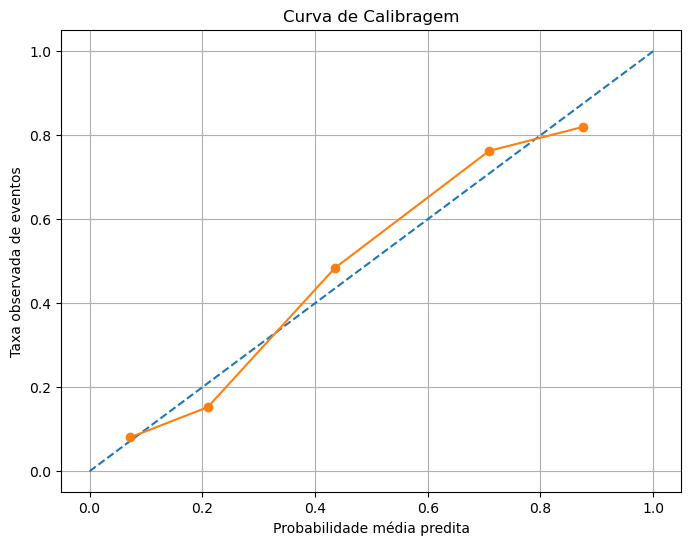

In [38]:
#Gráfico esperado vs observado
plt.figure(figsize=(8,6))

# linha perfeita
plt.plot([0,1],
         [0,1],
         linestyle='--')

# pontos do modelo
plt.plot(calibragem['prob_media_predita'],
         calibragem['taxa_observada'],
         marker='o')

plt.xlabel('Probabilidade média predita')
plt.ylabel('Taxa observada de eventos')
plt.title('Curva de Calibragem')

plt.grid(True)

plt.show()

5. Avalie o seu modelo quanto a discriminação calculando acurácia, GINI e KS.

In [45]:

# =========================================
# Acurácia
# =========================================

# transformando probabilidade em classe
df['pred_classe'] = (df['prob_predita'] >= 0.5).astype(int)

acuracia = accuracy_score(df['flag_doente'],
                          df['pred_classe'])

print(f'Acurácia: {acuracia:.4f}')

# =========================================
# GINI
# =========================================

auc = roc_auc_score(df['flag_doente'],
                    df['prob_predita'])

gini = 2 * auc - 1

print(f'AUC: {auc:.4f}')
print(f'GINI: {gini:.4f}')

# =========================================
# KS
# =========================================

# probabilidades dos grupos
prob_doentes = df.loc[df['flag_doente'] == 1,
                      'prob_predita']

prob_saudaveis = df.loc[df['flag_doente'] == 0,
                        'prob_predita']

# estatística KS
ks = ks_2samp(prob_doentes,
              prob_saudaveis)

print(f'KS: {ks.statistic:.4f}')

Acurácia: 0.7954
AUC: 0.8519
GINI: 0.7039
KS: 0.5930


6. tente melhorar o modelo obtido, por exemplo inserindo ou removendo variáveis.  
    Avalie as características do seu modelo (calibragem e acurácia).

In [47]:
# Além disso, algumas variáveis possuem valores "?", então precisamos tratá-las antes.
# substituindo ? por NaN
df = df.replace('?', np.nan)

# convertendo colunas para numéricas
colunas = ['ca', 'thal']

for col in colunas:
    df[col] = pd.to_numeric(df[col])

# removendo missing
df_modelo = df.dropna()

In [49]:
# Novo modelo logístico
modelo2 = smf.logit(
    '''
    flag_doente ~
    age +
    trestbps +
    thalach +
    oldpeak +
    C(sex) +
    C(cp) +
    C(exang) +
    ca
    ''',
    data=df_modelo
).fit()

modelo2.summary()

Optimization terminated successfully.
         Current function value: 0.366902
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            flag_doente   No. Observations:                  297
Model:                          Logit   Df Residuals:                      286
Method:                           MLE   Df Model:                           10
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.4684
Time:                        21:39:46   Log-Likelihood:                -108.97
converged:                       True   LL-Null:                       -204.97
Covariance Type:            nonrobust   LLR p-value:                 7.474e-36
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -3.4323      2.512     -1.366      0.172      -8.357       1.492
C(sex)[T.1.0]       1.6258      0.413      3.932      0.000       0.815       2.436
C(cp)[T.2.0]        0.9122      0.721      1.266      0.206      -0.501       2.325
C(cp)[T.3.0]        0.2263      0.629      0.360      0.719      -1.006       1.458
C(cp)[T.4.0]        2.1115      0.625      3.377      0.001       0.886       3.337
C(exang)[T.1.0]     0.8874      0.406      2.188      0.029       0.092       1.682
age                -0.0040      0.023     -0.174      0.861      -0.049       0.041
trestbps            0.0243      0.010      2.324      0.020       0.004       0.045
thalach            -0.0238      0.010     -2.403      0.016      -0.043      -0.004
oldpeak             0.5738      0.190      3.013      0.003       0.201       0.947
ca                  1.0842      0.232      4.678      0.000       0.630       1.538
===================================================================================
"""

In [51]:
#Probabilidades preditas
df_modelo['prob_predita2'] = modelo2.predict(df_modelo)

C:\Users\olive\AppData\Local\Temp\ipykernel_20180\2881994152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo['prob_predita2'] = modelo2.predict(df_modelo)


In [53]:
# Avaliação da acurácia
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# classe prevista
df_modelo['pred_classe2'] = (
    df_modelo['prob_predita2'] >= 0.5
).astype(int)

# acurácia
acuracia2 = accuracy_score(
    df_modelo['flag_doente'],
    df_modelo['pred_classe2']
)

print(f'Acurácia: {acuracia2:.4f}')

# AUC
auc2 = roc_auc_score(
    df_modelo['flag_doente'],
    df_modelo['prob_predita2']
)

# GINI
gini2 = 2 * auc2 - 1

print(f'AUC: {auc2:.4f}')
print(f'GINI: {gini2:.4f}')

Acurácia: 0.8316
AUC: 0.9148
GINI: 0.8297


C:\Users\olive\AppData\Local\Temp\ipykernel_20180\2266549889.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo['pred_classe2'] = (


In [55]:
#Avaliação da calibragem
# grupos de probabilidade
df_modelo['grupo_prob2'] = pd.qcut(
    df_modelo['prob_predita2'],
    q=5,
    duplicates='drop'
)

# tabela de calibragem
calibragem2 = df_modelo.groupby(
    'grupo_prob2',
    observed=False
).agg(
    prob_media_predita=('prob_predita2', 'mean'),
    taxa_observada=('flag_doente', 'mean')
)

calibragem2

C:\Users\olive\AppData\Local\Temp\ipykernel_20180\2377682654.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo['grupo_prob2'] = pd.qcut(


,prob_media_predita,taxa_observada
grupo_prob2,,
"(0.00377, 0.0879]",0.043818,0.050000
"(0.0879, 0.238]",0.154276,0.118644
"(0.238, 0.512]",0.362694,0.389831
"(0.512, 0.922]",0.773539,0.779661
"(0.922, 0.999]",0.970516,0.966667


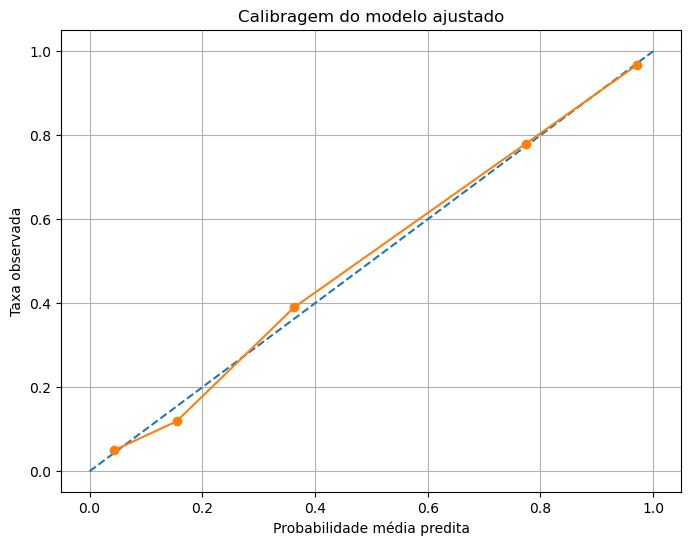

In [57]:
#Gráfico de calibragem
plt.figure(figsize=(8,6))

# linha ideal
plt.plot([0,1],
         [0,1],
         linestyle='--')

# curva do modelo
plt.plot(
    calibragem2['prob_media_predita'],
    calibragem2['taxa_observada'],
    marker='o'
)

plt.xlabel('Probabilidade média predita')
plt.ylabel('Taxa observada')
plt.title('Calibragem do modelo ajustado')

plt.grid(True)

plt.show()